In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [77]:
df = pd.read_csv("/AIML Dataset.csv")

In [78]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97225 entries, 0 to 97224
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            97225 non-null  int64  
 1   type            97225 non-null  object 
 2   amount          97225 non-null  float64
 3   nameOrig        97225 non-null  object 
 4   oldbalanceOrg   97225 non-null  float64
 5   newbalanceOrig  97225 non-null  float64
 6   nameDest        97225 non-null  object 
 7   oldbalanceDest  97225 non-null  float64
 8   newbalanceDest  97224 non-null  float64
 9   isFraud         97224 non-null  float64
 10  isFlaggedFraud  97224 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 8.2+ MB


In [80]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [81]:
df["isFraud"].value_counts()

,count
isFraud,
0.0,97110
1.0,114


In [82]:
df["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0.0,97224


In [83]:
df.isnull().sum().sum()

np.int64(3)

In [84]:
df.shape[0]

97225

In [85]:
round((df["isFraud"].value_counts() [1] / df.shape[0])*100,2)

np.float64(0.12)

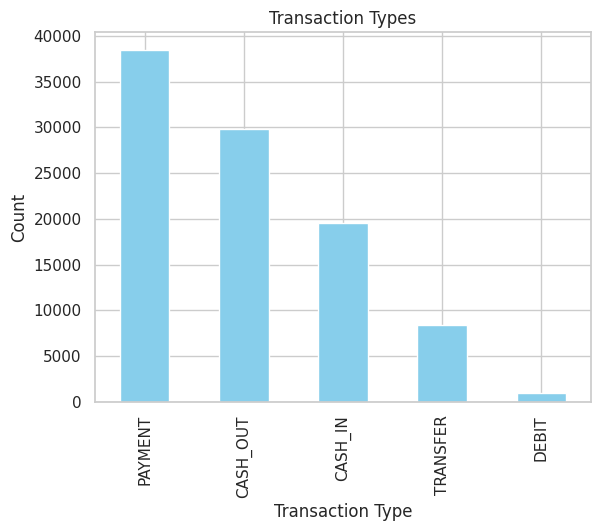

In [86]:
df["type"].value_counts().plot(kind="bar", title="Transaction Types", color="skyblue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

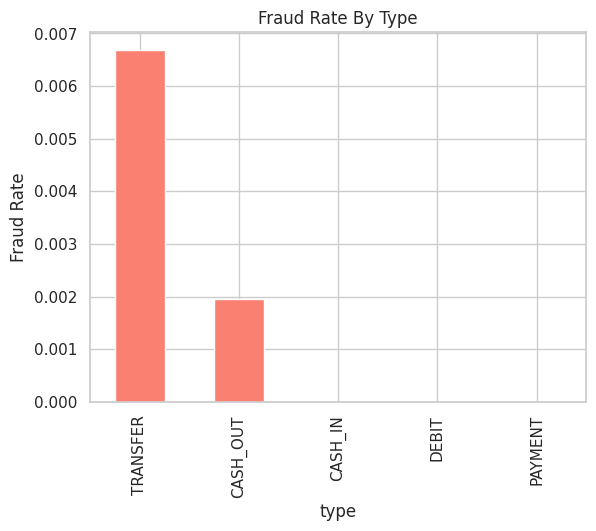

In [89]:
fraud_by_type = df.groupby("type") ["isFraud"] .mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate By Type", color="salmon")
plt.ylabel("Fraud Rate")
plt.show()

In [90]:
df["amount"].describe()

,amount
count,9.722500e+04
mean,1.724217e+05
std,3.419651e+05
min,3.200000e-01
25%,9.893120e+03
50%,5.208135e+04
75%,2.103607e+05
max,1.000000e+07


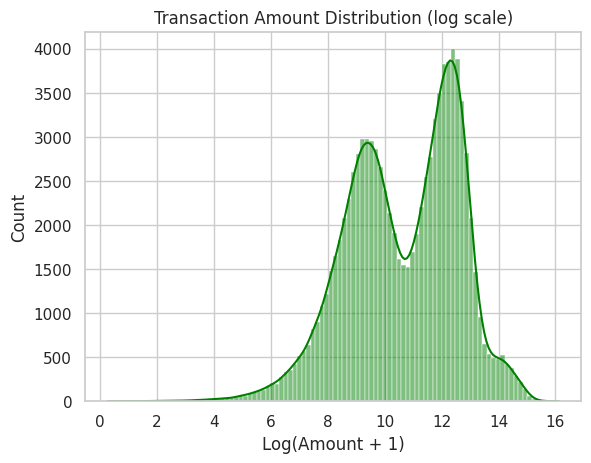

In [91]:
sns.histplot(np.log1p(df["amount"]) , bins =100 , kde=True , color ="green")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("Log(Amount + 1)")
plt.show()

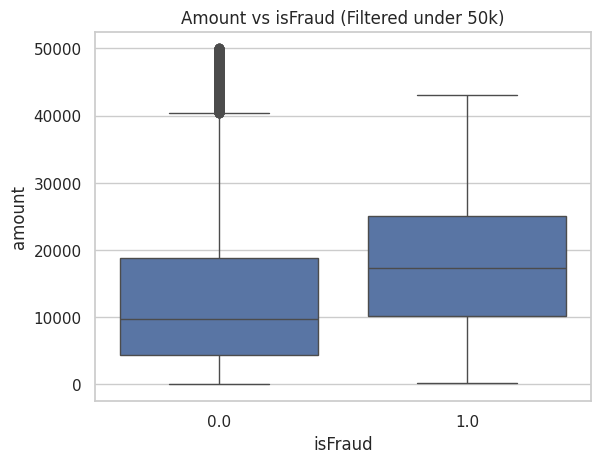

In [92]:
sns.boxplot(data=df[df["amount"] <50000], x="isFraud", y="amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

In [93]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [94]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [95]:
(df["balanceDiffOrig"]< 0 ).sum()

np.int64(19536)

In [96]:
(df["balanceDiffDest"]< 0 ).sum()

np.int64(17980)

In [97]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


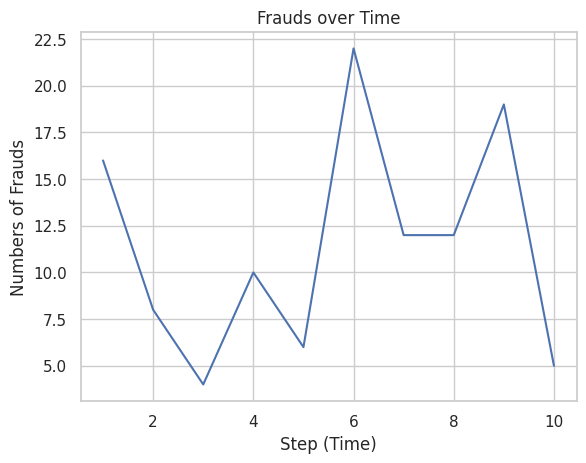

In [98]:
frauds_per_step = df[df["isFraud"] == 1] ["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index , frauds_per_step.values , label="Frauds per step")
plt.xlabel("Step (Time)")
plt.ylabel("Numbers of Frauds")
plt.title("Frauds over Time")
plt.grid(True)
plt.show()

In [99]:
df.drop(columns="step",inplace=True)

In [100]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


In [101]:
top_senders= df["nameOrig"].value_counts().head(10)

In [102]:
top_senders

,count
nameOrig,
C708911726,1
C1231006815,1
C1666544295,1
C1305486145,1
C840083671,1
C2048537720,1
C90045638,1
C154988899,1
C1912850431,1


In [103]:
top_recevivers= df["nameDest"].value_counts().head(10)

In [104]:
top_recevivers

,count
nameDest,
C985934102,78
C1286084959,71
C248609774,71
C1590550415,69
C2083562754,66
C665576141,65
C977993101,65
C1360767589,62
C451111351,60


In [105]:
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])]

In [106]:
fraud_types["type"].value_counts()

,count
type,
CASH_OUT,29839
TRANSFER,8371


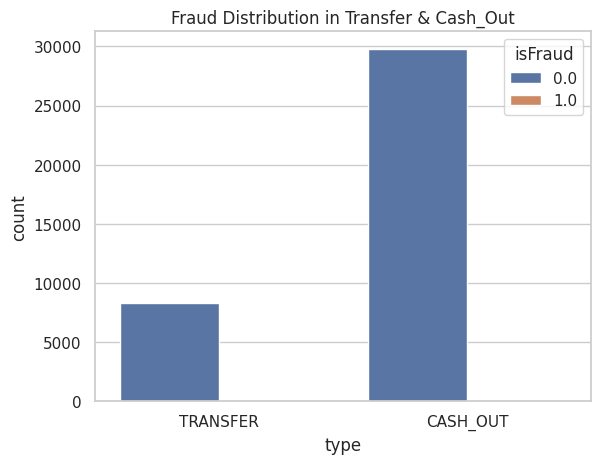

In [107]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in Transfer & Cash_Out")
plt.show()

In [108]:
print(df.head())

       type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2  TRANSFER    181.00  C1305486145          181.0            0.00   
3  CASH_OUT    181.00   C840083671          181.0            0.00   
4   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  \
0  M1979787155             0.0             0.0      0.0             0.0   
1  M2044282225             0.0             0.0      0.0             0.0   
2   C553264065             0.0             0.0      1.0             0.0   
3    C38997010         21182.0             0.0      1.0             0.0   
4  M1230701703             0.0             0.0      0.0             0.0   

   balanceDiffOrig  balanceDiffDest  
0          9839.64              0.0  
1          1864.28              0.0  
2           181.00  

In [109]:
corr = df[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()

In [110]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.010429,-0.016750,0.246539,0.372186,0.037054
oldbalanceOrg,-0.010429,1.000000,0.998870,0.105867,0.074727,-0.004149
newbalanceOrig,-0.016750,0.998870,1.000000,0.107544,0.073765,-0.010878
oldbalanceDest,0.246539,0.105867,0.107544,1.000000,0.939316,-0.009241
newbalanceDest,0.372186,0.074727,0.073765,0.939316,1.000000,-0.006323
isFraud,0.037054,-0.004149,-0.010878,-0.009241,-0.006323,1.000000


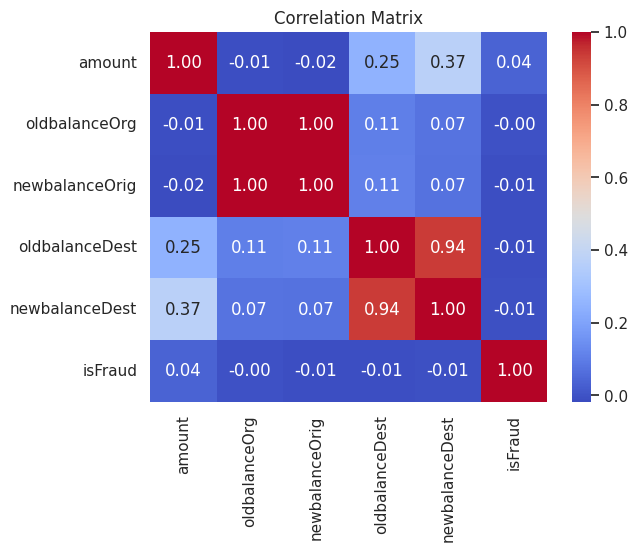

In [111]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [112]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] > 0) &
    (df["type"].isin(["TRANSFER","CASH_OUT"]))
]

In [113]:
len(zero_after_transfer)

4207

In [114]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
58,TRANSFER,62610.80,C1976401987,79114.00,16503.20,C1937962514,517.00,8383.29,0.0,0.0,62610.80,7866.29
70,CASH_OUT,47458.86,C527211736,209534.84,162075.98,C2096057945,52120.00,0.00,0.0,0.0,47458.86,-52120.00
71,CASH_OUT,136872.92,C1533123860,162075.98,25203.05,C766572210,217806.00,0.00,0.0,0.0,136872.93,-217806.00
516,TRANSFER,7206.33,C478139423,24932.00,17725.67,C1032986144,21308.00,18161.79,0.0,0.0,7206.33,-3146.21
665,CASH_OUT,227768.63,C1445424568,1011466.31,783697.68,C1023714065,530123.48,1412484.09,0.0,0.0,227768.63,882360.61


In [115]:
df["isFraud"].value_counts()

,count
isFraud,
0.0,97110
1.0,114


In [116]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [117]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


In [118]:
df_model = df.drop(["nameOrig","nameDest","isFlaggedFraud"], axis = 1)

In [119]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1.0,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1.0,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0.0,11668.14,0.0


In [120]:
categorical = ["type"]
numeric = ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

In [121]:
y = df_model["isFraud"]
X = df_model.drop("isFraud",axis=1)

In [124]:
X_train , X_test , y_train , y_test = train_test_split(X_cleaned, y_cleaned , test_size=0.3, stratify=y_cleaned)

In [126]:
preprocessor = ColumnTransformer(
    transformers= [
        ("num", StandardScaler(),numeric),
        ("cat", OneHotEncoder(drop="first"),categorical)
    ],
    remainder= "drop"
)

In [127]:
pipeline = Pipeline([
    ("prep",preprocessor),
    ("clf",LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [128]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [130]:
y_pred = pipeline.predict(X_test)

In [132]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.82      0.90     29134
         1.0       0.01      1.00      0.01        34

    accuracy                           0.82     29168
   macro avg       0.50      0.91      0.46     29168
weighted avg       1.00      0.82      0.90     29168



In [133]:
confusion_matrix(y_test,y_pred)

array([[23807,  5327],
       [    0,    34]])

In [135]:
pipeline.score(X_test, y_test) * 100

81.736834887548

In [136]:
import joblib

joblib.dump(pipeline,"fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']

In [137]:
import os
os.listdir()

['.config', 'fraud_detection_pipeline.pkl', 'sample_data']

In [138]:
from google.colab import files
files.download("fraud_detection_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>